In [14]:
import numpy as np 
#import cupy as cp
import matplotlib.pyplot as plt
from scipy.special import jv

import os
import re
import sys

In [33]:
E = 200
z = 0.5
Lp = 4 * E * z * (1 - z)
omega = E * z * (1 - z)
vertex = "gamma_qq"
mu = 0.15
t = 2
Np = 512

#htl_str = "data/fsol_final_htl_" + vertex + "__E_" + str(int(E)) + "_z_" + str(z) + "_q_1.5_mu_0.2.dat"
#yuk_str = "data/fsol_final_yuk_" + vertex + "__E_" + str(int(E)) + "_z_" + str(z) + "_q_0.5_mu_0.3.dat"
#yuk_str2 = "data/fsol_final_yuk_" + vertex + "__E_" + str(int(E)) + "_z_" + str(z) + "_q_2.5_mu_0.3.dat"
#yuk_str3 = "data/fsol_final_yuk_" + vertex + "__E_" + str(int(E)) + "_z_" + str(z) + "_q_1.5_mu_0.3.dat"

ho_str = "data/fsol_final_ho_" + vertex + "__E_" + str(int(E)) + "_z_0.5_q_1.5_mu_0.3.dat"
# ho_str2 = "data/fsol_final_ho_" + vertex + "__E_" + str(int(E)) + "_z_0.3_q_1.5_mu_0.9.dat"
# ho_str3 = "data/fsol_final_ho_" + vertex + "__E_" + str(int(E)) + "_z_0.3_q_1.5_mu_0.3.dat"
# ho_str4 = "data/fsol_final_ho_" + vertex + "__E_" + str(int(E)) + "_z_0.3_q_1.5_mu_0.15.dat"
#ho_str4 = "data/fsol_final_ho_" + vertex + "__E_" + str(int(E)) + "_z_0.3_q_1.5_mu_0.06.dat"


#htl = np.loadtxt(htl_str).T[0] + 1j * np.loadtxt(htl_str).T[1]
# yuk = np.loadtxt(yuk_str).T[0] + 1j * np.loadtxt(yuk_str).T[1]
# yuk2 = np.loadtxt(yuk_str2).T[0] + 1j * np.loadtxt(yuk_str2).T[1]
#yuk3 = np.loadtxt(yuk_str3).T[0] + 1j * np.loadtxt(yuk_str3).T[1]

ho  = np.loadtxt(ho_str).T[0] + 1j * np.loadtxt(ho_str).T[1]
# ho2  = np.loadtxt(ho_str2).T[0] + 1j * np.loadtxt(ho_str2).T[1]
# ho3  = np.loadtxt(ho_str3).T[0] + 1j * np.loadtxt(ho_str3).T[1]
# ho4  = np.loadtxt(ho_str4).T[0] + 1j * np.loadtxt(ho_str4).T[1]

#Np = len(yuk)
P = np.linspace(0, Lp, Np, dtype=np.float64)


In [31]:
CF = 3/2

def in_out_harmonic(p, t, omega, qtilde):
    qab = 0
    if vertex == "gamma_qq":
        qab =CF * qtilde * 5.067**2
    elif vertex == "q_qg":
        qab = (3 * (1-z) + CF * z**2) * qtilde * 5.067**2
    else:
        qab = CF * (1 + z**2 + (1-z)**2) * qtilde * 5.067**2
    omega = omega * 5.067
    p = p * 5.067
    Omega = (1-1j)/2 * np.sqrt(qab/omega)

    return -2*(1 - np.exp(-1j/(2*omega*Omega) * np.tan(Omega * t) * p**2))



/tmp/ipykernel_2416861/2258830172.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


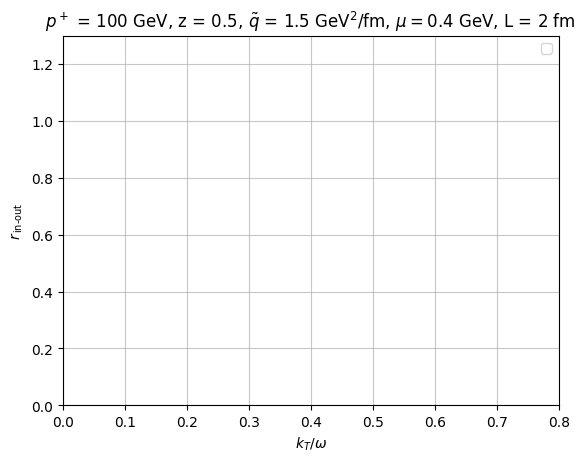

In [29]:
#plt.plot(P[:-10]/omega , np.real(htl[:-10]/yuk[:-10]), label='Ratio HTL/Yuk', color = "red")

#plt.plot(P[:-10], -2+ 2*0.4**4/(0.002*P[:-10]**2 + 0.4**2)**2)
plt.xlabel(r'$k_T/\omega$')
plt.ylim(0, 1.3)
plt.xlim(0, 0.8)
plt.ylabel(r'$r_{\, \text{in-out}}$')
plt.legend()
plt.title(r'$p^+$ = 100 GeV, z = 0.5, $\tilde{q}$ = 1.5 GeV$^2$/fm, $\mu = 0.4$ GeV, L = 2 fm')
plt.grid(alpha = 0.7)

plt.show()

In [55]:
#plt.plot(P[:-10]/omega , np.real(ho[:-10]),  marker='o', linewidth = 1.75, markersize = 2, label='HO, num.', color = "orange")
#slt.plot(P[:-10]/omega , np.real(htl[:-10]), label='HTL', marker='^', markersize = 3, color = "red")
plt.plot(P[:-10]/omega ,np.real(yuk[:-10]),  marker='p', markersize = 4, label='Yukawa', color = "green")
plt.plot(P[:-10]/omega, np.real(IN_OUT_HO[:-10]) / (P[:-10]/omega)  , "--", label='HO, analytical', color = "blue", linewidth = 1)

#plt.plot(P[:-10], -2+ 2*0.4**4/(0.002*P[:-10]**2 + 0.4**2)**2)
plt.xlabel(r'$p/\omega$')
plt.xlim(0, 4.0)
plt.ylabel(r'$j(|p|)$')
plt.legend()
plt.title(r'$p^+$ = 200 GeV, z = 0.5, $\tilde{q}$ = 1.5 GeV$^2$/fm, L = 2 fm')
plt.grid(alpha = 0.7)

plt.show()

NameError: name 'yuk' is not defined

In [30]:
from scipy.interpolate import CubicSpline

# create cub<ic splines for real and imaginary parts separately
yuk_real = np.real(yuk)
yuk_imag = np.imag(yuk)

_yuk_cs_real = CubicSpline(P, yuk_real, extrapolate=True)
_yuk_cs_imag = CubicSpline(P, yuk_imag, extrapolate=True)

def yuk_spline(p):
    """
    Interpolator for complex array `yuk` as a function of `P`.
    Accepts scalar or array-like `p` (same units as P) and returns complex values.
    Example:
        val = yuk_spline(10.5)           # scalar
        vals = yuk_spline([1.0, 2.5, 4]) # array-like
    """
    p_arr = np.asarray(p)
    return _yuk_cs_real(p_arr) + 1j * _yuk_cs_imag(p_arr)

NameError: name 'yuk' is not defined

In [25]:
def s(k, l, psi):
    R = np.sqrt(k**2 + l**2 + 2*k*l*np.cos(psi) + 1e-8)

    return (k**2 - l**2)/R * yuk_spline(R)

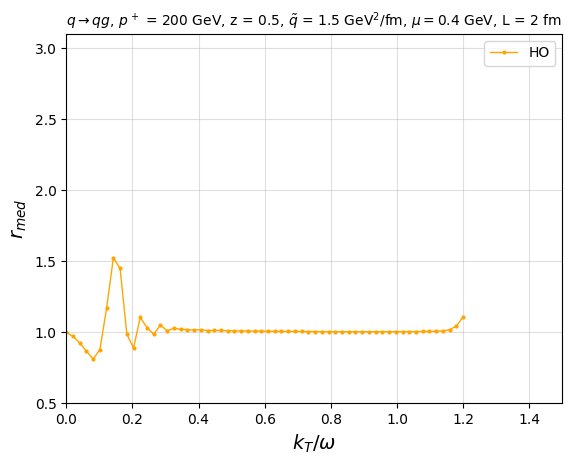

In [34]:
from scipy.interpolate import CubicSpline

#interpolate P[:-10]/omega , P[:-10]/omega*np.real(yuk[:-10]) with spline 
data_ho = np.loadtxt("data/fsol3D_final_ho_gamma_qq__E_200_z_0.5_q_1.5_mu_0.3_L_2.dat").T
# data_yuk = np.loadtxt("data/fsol3D_final_yuk_q_qg__E_200_z_0.02_q_0.5_mu_0.3_L_4.dat").T
# data_yuk2 = np.loadtxt("data/fsol3D_final_yuk_q_qg__E_200_z_0.02_q_2.5_mu_0.3_L_4.dat").T
#data_yuk3 = np.loadtxt("data/fsol3D_final_yuk_q_qg__E_200_z_0.5_q_1.5_mu_0.3_L_2.dat").T

#data_htl = np.loadtxt("data/fsol3D_final_htl_q_qg__E_200_z_0.5_q_1.5_mu_0.4.dat").T


K = P[:-10] / omega
In_out_ho = P[:-10]/omega * np.real(ho[:-10])
# In_out_yuk = P[:-10]/omega*np.real(yuk[:-10])
# In_out_yuk2 = P[:-10]/omega*np.real(yuk2[:-10])
#In_out_yuk3 = P[:-10]/omega*np.real(yuk3[:-10])

#In_out_htl = P[:-10]/omega * np.real(htl[:-10])

_ho_cs = CubicSpline(K, In_out_ho, extrapolate=False)
# _yuk_cs = CubicSpline(K, In_out_yuk, extrapolate=False)
# _yuk2_cs = CubicSpline(K, In_out_yuk2, extrapolate=False)
#_yuk3_cs = CubicSpline(K, In_out_yuk3, extrapolate=False)

#_htl_cs = CubicSpline(K, In_out_htl, extrapolate=True)


ratio = 0.3
#Kout = np.linspace(0, ratio * Lp, 60, dtype=np.float64)
N = len(K)


# f_in_yuk = data_yuk.T
# f_in_yuk2 = data_yuk2.T
#f_in_yuk3 = data_yuk3.T

f_in_ho = data_ho.T
#f_in_htl = data_htl.T

#f_out_yuk = np.zeros_like(f_in_yuk)
#f_out_yuk2 = np.zeros_like(f_in_yuk)
#f_out_yuk3 = np.zeros_like(f_in_yuk3)
f_out_ho = np.zeros_like(f_in_ho)
#f_out_htl = np.zeros_like(f_in_htl)
K = np.linspace(0, ratio * Lp, 60, dtype=np.float64)

for i in range(len(K)):
    # f_out_yuk[i] = _yuk_cs(K[i]/omega)
    # f_out_yuk2[i] = _yuk2_cs(K[i]/omega)
    #f_out_yuk3[i] = _yuk3_cs(K[i]/omega)
    f_out_ho[i] = _ho_cs(K[i]/omega)
    #f_out_htl[i] = _htl_cs(K[i]/omega)


# d = f_in_yuk
# d2 = f_in_yuk2
# d3 = f_in_yuk3
# for _ in range(4):
#     d = np.gradient(K**2/omega**2 * d, K/omega, axis=0)
#     d2 = np.gradient(K**2/omega**2 * d2, K/omega, axis=0)
#     d3 = np.gradient(K**2/omega**2 * d3, K/omega, axis=0)
# f_in_yuk_d4 = d
# f_in_yuk2_d4 = d2
# f_in_yuk3_d4 = d3

# quick check
# print("f_in_yuk_d4.shape =", f_in_yuk_d4.shape)
# print("f_in_yuk_d4 (first 5 rows):\n", f_in_yuk_d4[:5])

# #plt.plot(f_in_yuk)
# #plt.plot(f_in_yuk_d4)

# unc = (0.5 * f_in_yuk_d4) * (K[1]-K[0])/omega
# unc2 = (0.5 * f_in_yuk2_d4) * (K[1]-K[0])/omega
# unc3 = (0.5 * f_in_yuk3_d4) * (K[1]-K[0])/omega




plt.plot(K/omega, (1 + f_out_ho + 0.5 * K**2 / omega**2 * f_in_ho), marker = 'o', linewidth = 1, markersize = 2, label='HO', color = "orange")
#plt.plot(K/omega, (1 + f_out_yuk + 0.5 * K**2/omega**2 * f_in_yuk), markersize = 3, linewidth = 1.5, label=r'Yukawa $q = 0.5$ GeV', color = "green")
#plt.fill_between(K/omega, (1 + f_out_yuk + 0.5 * K**2/omega**2 * f_in_yuk) + unc, (1 + f_out_yuk + 0.5 * K**2/omega**2 * f_in_yuk) - unc, color = "green", alpha = 0.3)
#plt.plot(K/omega, (1 + f_out_yuk3 + 0.5 * K**2/omega**2 * f_in_yuk3), markersize = 3, linewidth = 2, label=r'Yukawa $q = 1.5$ GeV', color = "blue")
#plt.fill_between(K/omega, (1 + f_out_yuk3 + 0.5 * K**2/omega**2 * f_in_yuk3) + unc3, (1 + f_out_yuk3 + 0.5 * K**2/omega**2 * f_in_yuk3) - unc3, color = "blue", alpha = 0.3)
#plt.plot(K/omega, (1 + f_out_yuk2 + 0.5 * K**2/omega**2 * f_in_yuk2), markersize = 3, linewidth = 2, label=r'Yukawa $q = 2.5$ GeV', color = "red")
#plt.fill_between(K/omega, (1 + f_out_yuk2 + 0.5 * K**2/omega**2 * f_in_yuk2) + unc2, (1 + f_out_yuk2 + 0.5 * K**2/omega**2 * f_in_yuk2) - unc2, color = "red", alpha = 0.3)


#plt.plot(K/omega, 1 + f_out_htl + 0.5 * K**2/omega**2 * f_in_htl, marker = 's', markersize = 1, linewidth = 1, linestyle = "--", label='HTL', color = "red")

plt.title(r"$q \to qg, \, p^+$ = 200 GeV, z = 0.5, $\tilde{q}$ = 1.5 GeV$^2$/fm, $\mu = 0.4$ GeV, L = 2 fm", fontsize = 10)
plt.ylabel(r'$r_{med}$', fontsize = 14)
plt.xlabel(r'$k_T/\omega$', fontsize = 14)
plt.legend()
plt.xlim(0, 1.5)
plt.ylim(0.5, 3.1)

plt.grid(alpha = 0.4)
plt.savefig("rmed.png", dpi=300)
plt.show()



In [ ]:
3/2 * 0.5 * 2**2 / 2


1.5

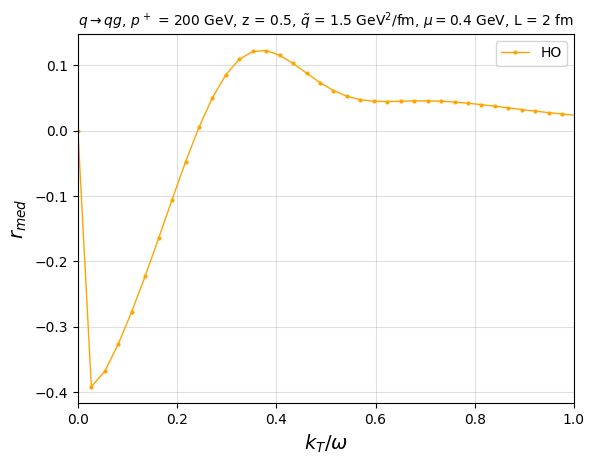

In [ ]:
def spectrum(z, theta):
    alphas = 0.3


    return alphas * CF / (2 * np.pi) * 1/(theta + 1e-6)

plt.plot(K/omega, spectrum(z, K/omega) * (f_out_yuk + 0.5 * K**2 / omega**2 * f_in_yuk), marker = 'o', linewidth = 1, markersize = 2, label='HO', color = "orange")

#plt.plot(K/omega, (1+ f_out_yuk + 0.5 * K**2/omega**2 * f_in_yuk), marker = 'o', markersize = 3, linewidth = 2, label='Yukawa', color = "green")
#plt.plot(K/omega, 1 + f_out_htl + 0.5 * K**2/omega**2 * f_in_htl, marker = 's', markersize = 1, linewidth = 1, linestyle = "--", label='HTL', color = "red")

plt.title(r"$q \to qg, \, p^+$ = 200 GeV, z = 0.5, $\tilde{q}$ = 1.5 GeV$^2$/fm, $\mu = 0.4$ GeV, L = 2 fm", fontsize = 10)
plt.ylabel(r'$r_{med}$', fontsize = 14)
plt.xlabel(r'$k_T/\omega$', fontsize = 14)
plt.legend()
plt.xlim(0, 1.)
plt.grid(alpha = 0.4)
plt.savefig("rmed.png", dpi=300)
plt.show()



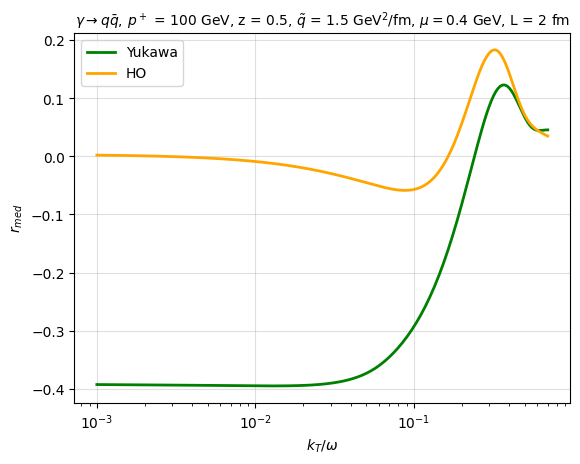

In [ ]:
#spline interpolation of 1 + f_out_yuk + 0.5 * K**2/omega**2 * f_in_yuk as and correspondent HO and HTL results, as a function of K/omega, for K in [0, 0.3*Lp]

_yuk_rmed = CubicSpline(K/omega, 1 + f_out_yuk + 0.5 * K**2/omega**2 * f_in_yuk, extrapolate=True)
_ho_rmed = CubicSpline(K/omega, 1 + f_out_ho + 0.5 * K**2/omega**2 * f_in_ho, extrapolate=True)
#_htl_rmed = CubicSpline(K/omega, 1 + f_out_htl + 0.5 * K**2/omega**2 * f_in_htl, extrapolate=True)

K_omega = np.e**(np.linspace(np.log(1e-3), np.log(0.7), 200, dtype=np.float64))

#plt.plot(K_omega, _ho_rmed(K_omega), label='HO, spline', color = "orange", linestyle = "--", linewidth = 1)
plt.plot(K_omega, spectrum(z, K_omega) * (_yuk_rmed(K_omega)-1), label='Yukawa', color = "green", linewidth = 2)
plt.plot(K_omega, spectrum(z, K_omega) * (_ho_rmed(K_omega)-1), label='HO', color = "orange", linewidth = 2)

#plt.plot(K_omega, _htl_rmed(K_omega), label='HTL, spline', color = "red", linestyle = "--", linewidth = 1)
plt.title(r"$\gamma \to q\bar{q}, \, p^+$ = 100 GeV, z = 0.5, $\tilde{q}$ = 1.5 GeV$^2$/fm, $\mu = 0.4$ GeV, L = 2 fm", fontsize = 10)
plt.ylabel(r'$r_{med}$')
plt.xlabel(r'$k_T/\omega$')
plt.legend()
plt.xscale("log")
plt.grid(alpha = 0.4)

plt.savefig("rmed_spline.png", dpi=300)

plt.show()

#plot the ratio between HTL and Yukawa 
# plt.plot(K_omega, _yuk_rmed(K_omega)/_htl_rmed(K_omega), label='HTL/Yukawa, spline', color = "purple", linestyle = "--", linewidth = 2)
# plt.title(r"$\gamma \to q\bar{q}, \, p^+$ = 100 GeV, z = 0.5, $\tilde{q}$ = 1.5 GeV$^2$/fm, $\mu = 0.4$ GeV, L = 2 fm", fontsize = 10)
# plt.ylabel(r'Ratio HTL/Yukawa')
# plt.xlabel(r'$k_T/\omega$')
# plt.legend()
# plt.xlim(0, 0.7)

# plt.ylim(0.98, 1.005)
# plt.grid(alpha = 0.4)
# plt.savefig("rmed_ratio.png", dpi=300)
# plt.show()

In [ ]:
K_omega = np.e**(np.linspace(np.log(1e-3), np.log(0.7), 200, dtype=np.float64))

print(K_omega)

[0.001      0.00103347 0.00106806 0.0011038  0.00114074 0.00117892
 0.00121838 0.00125915 0.0013013  0.00134485 0.00138986 0.00143637
 0.00148444 0.00153412 0.00158547 0.00163853 0.00169337 0.00175004
 0.00180861 0.00186914 0.0019317  0.00199635 0.00206316 0.00213221
 0.00220357 0.00227732 0.00235354 0.00243231 0.00251371 0.00259784
 0.00268478 0.00277464 0.0028675  0.00296347 0.00306265 0.00316515
 0.00327108 0.00338056 0.0034937  0.00361062 0.00373146 0.00385635
 0.00398541 0.00411879 0.00425664 0.0043991  0.00454633 0.00469848
 0.00485573 0.00501824 0.00518619 0.00535976 0.00553914 0.00572453
 0.00591612 0.00611412 0.00631874 0.00653022 0.00674877 0.00697464
 0.00720806 0.0074493  0.00769861 0.00795627 0.00822255 0.00849774
 0.00878214 0.00907606 0.00937982 0.00969374 0.01001817 0.01035345
 0.01069996 0.01105807 0.01142816 0.01181063 0.01220591 0.01261441
 0.01303659 0.0134729  0.01392381 0.01438981 0.0148714  0.01536912
 0.01588349 0.01641508 0.01696445 0.01753222 0.01811898 0.0187

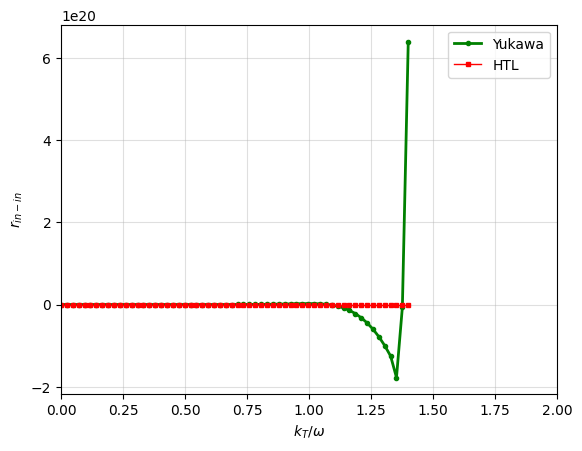

In [ ]:
plt.plot(K/omega, 0.5 * K**2/omega**2 * f_in_yuk, marker = 'o', markersize = 3, linewidth = 2, label='Yukawa', color = "green")
plt.plot(K/omega,  0.5 * K**2/omega**2 * f_in_htl, marker = 's', markersize = 3, linewidth = 1, label='HTL', color = "red")
plt.xlim(0, 2)
plt.ylabel(r'$r_{in-in}$')
plt.xlabel(r'$k_T/\omega$')
plt.legend()
plt.grid(alpha = 0.4)
plt.show()

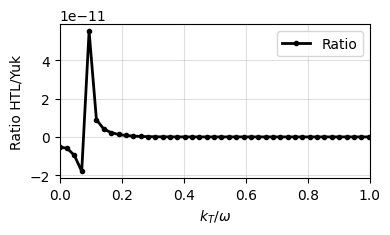

In [ ]:
plt.figure(figsize=(4, 2))
plt.plot(K/omega, f_in_htl/f_in_yuk, marker = 'o', markersize = 3, linewidth = 2, label='Ratio', color = "black")
plt.xlim(0, 1)
plt.ylabel(r'Ratio HTL/Yuk')
plt.xlabel(r'$k_T/\omega$')
plt.legend()
plt.grid(alpha = 0.4)
plt.savefig("ratio_inin.png", dpi=300, bbox_inches='tight')
plt.show()